# Dataset Research

Single notebook for dataset-level analysis: horizon comparison, label profiling,
feature–target intuition, segment-aware checks, and optional raw-data context.

Uses helpers from `src.analysis.io`, `src.analysis.market_context`, and `src.dataset.schema`.

## 1. Setup

In [2]:
import warnings
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from src.config.config import fetch_symbol_config
from src.analysis.io import load_dataset_with_meta
from src.analysis.market_context import (
    load_raw_events, parse_trades, replay_book_samples,
    attach_segment_id, label_profile, dataset_summary_row,
)
from src.dataset.schema import FEATURE_COLUMNS

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.6f}".format)
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

# --- Plotting helpers ---
def _fmt_xaxis(ax, tz_info, tz_name):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=tz_info))
    ax.set_xlabel(f"time ({tz_name})")

def _save_fig(fig, name, output_dir=None):
    if output_dir:
        fig.savefig(output_dir / f"{name}.png", bbox_inches="tight", dpi=150)

def _save_csv(df, name, output_dir=None):
    if output_dir:
        df.to_csv(output_dir / f"{name}.csv")

def _qrange(s, lo_q=0.01, hi_q=0.99):
    lo = s.quantile(lo_q) if lo_q > 0 else 0
    hi = s.quantile(hi_q)
    tag = f"p{lo_q*100:g}\u2013p{hi_q*100:g}"
    return lo, hi, tag

## 2. Configuration

In [ ]:
# --- Primary dataset ---
DATASET_PATH = Path("../data/datasets/binance/BTCUSDT_v2/dataset_i100_tw1000_w600_h1000.parquet")

# --- Horizon sweep: list parquets to compare (set to [] to skip) ---
HORIZON_SWEEP_PATHS = sorted(DATASET_PATH.parent.glob("dataset_i100_tw1000_w600_h*.parquet"))

# --- Raw data (set to None to skip raw sections entirely) ---
# Derived from dataset metadata by default; override here if needed.
RAW_DATA_PATH = None  # auto-detected from metadata in section 3

# --- Reference price for bps conversion ---
# Default: median midprice from book replay. Override here if needed.
REF_PRICE = None

# --- Display ---
TIMEZONE = "UTC"
PLOT_RESAMPLE = "5min"

# --- Output ---
SAVE_OUTPUTS = False
OUTPUT_DIR = None  # set in section 3 after SYMBOL is known

_TZ = ZoneInfo(TIMEZONE)

print(f"Primary dataset: {DATASET_PATH}")
print(f"Horizon sweep:   {[p.name for p in HORIZON_SWEEP_PATHS]}")

Primary dataset: ../data/datasets/binance/BTCUSDT_v2/dataset_i100_tw1000_w600_h1000.parquet
Horizon sweep:   ['dataset_i100_tw1000_w600_h1000.parquet', 'dataset_i100_tw1000_w600_h200.parquet', 'dataset_i100_tw1000_w600_h500.parquet']


## 3. Load primary dataset

In [4]:
ds, ds_meta = load_dataset_with_meta(DATASET_PATH)

# --- Symbol & config from metadata ---
SYMBOL = ds_meta["symbol"]
cfg = fetch_symbol_config(SYMBOL)
tick_size = float(cfg.tick_size)
step_size = float(cfg.step_size)

# --- Raw data path from metadata (if not overridden in config) ---
if RAW_DATA_PATH is None and "data_path" in ds_meta:
    RAW_DATA_PATH = Path("..") / ds_meta["data_path"]
    print(f"Raw data path (from metadata): {RAW_DATA_PATH}")

# --- Output dir ---
if SAVE_OUTPUTS:
    OUTPUT_DIR = Path(f"../reports/dataset_research/{SYMBOL}")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Book replay for reference price and raw context ---
HAS_RAW = RAW_DATA_PATH is not None and Path(RAW_DATA_PATH).exists()
if HAS_RAW:
    raw_df = load_raw_events(RAW_DATA_PATH)
    trades = parse_trades(raw_df)
    book_df = replay_book_samples(RAW_DATA_PATH, cfg, sample_ms=1000)
    book_df["spread_usd"] = book_df["spread_ticks"] * tick_size
    book_df["log_return"] = book_df.groupby("segment_id")["midprice"].transform(
        lambda s: np.log(s / s.shift(1))
    )
    print(f"Events: {len(raw_df):,}  |  Trades: {len(trades):,}")
    print(f"Book samples: {len(book_df):,}  |  Segments: {book_df.segment_id.nunique()}")

# --- Reference price ---
if REF_PRICE is not None:
    ref_price = REF_PRICE
elif HAS_RAW:
    ref_price = book_df["midprice"].median()
    print(f"ref_price = median(midprice) from book replay: {ref_price:,.2f} USDT")
else:
    raise ValueError("REF_PRICE must be set explicitly when raw data is not available")

interval_ms = int(ds_meta.get("interval_ms", 100))
horizon_ms = ds_meta.get("horizon_ms", "?")

print(f"\nSymbol: {SYMBOL}  tick={cfg.tick_size}  step={cfg.step_size}")
print(f"Rows: {len(ds):,}  |  interval={interval_ms}ms  horizon={horizon_ms}ms")
print(f"Time: {ds.datetime.min()} — {ds.datetime.max()}")
print(f"Ref price: {ref_price:,.2f} USDT")
print(f"\nMetadata:")
for k, v in sorted(ds_meta.items()):
    print(f"  {k}: {v}")

Raw data path (from metadata): ../data/raw/binance/BTCUSDT_v2


Book replay: 100%|██████████| 39720/39720 [04:22<00:00, 151.23it/s]


Events: 20,273,834  |  Trades: 16,270,563
Book samples: 400,426  |  Segments: 8
ref_price = median(midprice) from book replay: 69,899.99 USDT

Symbol: BTCUSDT  tick=0.01  step=0.00001
Rows: 1,686,870  |  interval=100ms  horizon=1000ms
Time: 2026-03-23 20:37:35.300000+00:00 — 2026-03-25 20:27:37.100000+00:00
Ref price: 69,899.99 USDT

Metadata:
  bootstrap_count: 5
  data_path: data/raw/binance/BTCUSDT_v2
  horizon_ms: 1000
  interval_ms: 100
  rows_dropped_missing_required: 0
  rows_kept: 1686870
  rows_seen: 1686870
  sequence_gaps: 0
  step_size: 0.00001
  symbol: BTCUSDT
  tick_size: 0.01
  trade_window_ms: 1000
  warmup_s: 600


## 4. Horizon sweep

Compare datasets built with different label horizons.  
All share the same raw data and features — only the label changes.

### Label unit conversions

- `label_ticks = label / tick_size` — how many ticks the midprice moved  
- `label_bps = 1e4 * label / ref_price` — approximate bps using a **fixed reference price**

**`ref_price`:** median midprice from book replay over the full raw recording period.
This is a single scalar used for all rows — adequate when the midprice stays within ~1%
of the median. For multi-day data with large drift, per-row midprice-based bps would be
more accurate.

In [5]:
if not HORIZON_SWEEP_PATHS:
    print("No horizon sweep paths configured — skipping.")
    sweep_df = pd.DataFrame()
    sweep_data = {}
else:
    sweep_rows = []
    sweep_data = {}  # horizon_ms -> (df, meta)
    for p in HORIZON_SWEEP_PATHS:
        df_h, meta_h = load_dataset_with_meta(p)
        attach_segment_id(df_h, int(meta_h.get("interval_ms", 100)))
        sweep_data[meta_h.get("horizon_ms", p.stem)] = (df_h, meta_h)
        row = dataset_summary_row(df_h, meta_h)
        # Add label profile fields
        lp_h = label_profile(df_h)
        row["label_abs_mean"] = lp_h["mean"]  # already in dataset_summary_row but keep profile too
        row.name = f"h={meta_h.get('horizon_ms', '?')}ms"
        sweep_rows.append(row)
    sweep_df = pd.DataFrame(sweep_rows)
    sweep_df = sweep_df.sort_values(by="horizon_ms")

    # Display columns of interest for horizon comparison
    display_cols = [
        "rows", "horizon_ms", "start", "end", "duration_s",
        "label_abs_mean", "label_std", "label_zero_pct",
        "label_pos_pct", "label_neg_pct",
        "bootstrap_count", "sequence_gaps", "segment_count", "max_gap_ms",
    ]
    display_cols = [c for c in display_cols if c in sweep_df.columns]
    print("=== Horizon Sweep Summary ===")
    with pd.option_context("display.width", 220, "display.max_columns", 20):
        print(sweep_df[display_cols].to_string())
    _save_csv(sweep_df, "horizon_sweep", OUTPUT_DIR)

=== Horizon Sweep Summary ===
             rows  horizon_ms                            start                              end    duration_s  label_abs_mean  label_std  label_zero_pct  label_pos_pct  label_neg_pct bootstrap_count sequence_gaps  segment_count     max_gap_ms
h=200ms   1686910         200 2026-03-23 20:37:35.300000+00:00 2026-03-25 20:27:37.900000+00:00 172202.600000       -0.000372   1.857255        0.917249       0.040791       0.041960               5             0              5 1595700.000000
h=500ms   1686895         500 2026-03-23 20:37:35.300000+00:00 2026-03-25 20:27:37.600000+00:00 172202.300000       -0.000932   3.229544        0.836753       0.080770       0.082478               5             0              5 1596000.000000
h=1000ms  1686870        1000 2026-03-23 20:37:35.300000+00:00 2026-03-25 20:27:37.100000+00:00 172201.800000       -0.001880   4.871586        0.733448       0.132254       0.134298               5             0              5 1596500.00000

### 4b. Small-move / tradeability table

For each horizon, what fraction of labels falls below fee thresholds?

- `fee_bps` is a **research proxy** (not the actual exchange fee schedule).  
  Binance taker fee is ~2-4.5 bps depending on tier; we use a round number for comparison.  
- Rows where `|label_bps| < fee_bps` are effectively untradeable — the expected move  
  does not cover the round-trip cost.

In [6]:
# Fee proxy: round-trip taker cost for research comparison
FEE_BPS = 4.0  # ~2 bps per leg, conservative

if sweep_data:
    trade_rows = []
    for h_key, (df_h, meta_h) in sorted(sweep_data.items(), key=lambda x: int(x[0])):
        lbl = df_h["label"]
        lbl_ticks = lbl / tick_size
        lbl_bps = lbl / ref_price * 1e4
        abs_ticks = lbl_ticks.abs()
        abs_bps = lbl_bps.abs()
        n = len(lbl)
        trade_rows.append({
            "horizon_ms": int(h_key),
            "label == 0": f"{(lbl == 0).sum() / n:.1%}",
            "|ticks| < 1": f"{(abs_ticks < 1).sum() / n:.1%}",
            "|ticks| < 2": f"{(abs_ticks < 2).sum() / n:.1%}",
            f"|bps| < {FEE_BPS}": f"{(abs_bps < FEE_BPS).sum() / n:.1%}",
            f"|bps| < {2*FEE_BPS}": f"{(abs_bps < 2 * FEE_BPS).sum() / n:.1%}",
            "mean |bps|": f"{abs_bps.mean():.3f}",
            "mean |ticks|": f"{abs_ticks.mean():.1f}",
        })
    trade_df = pd.DataFrame(trade_rows).set_index("horizon_ms")
    print(f"=== Tradeability Table (fee_bps={FEE_BPS}, ref_price={ref_price:,.0f}) ===")
    print(trade_df.to_string())
else:
    print("No sweep data — skipping tradeability table.")

=== Tradeability Table (fee_bps=4.0, ref_price=69,900) ===
           label == 0 |ticks| < 1 |ticks| < 2 |bps| < 4.0 |bps| < 8.0 mean |bps| mean |ticks|
horizon_ms                                                                                   
200             91.7%       91.7%       91.9%      100.0%      100.0%      0.055         38.5
500             83.7%       83.7%       84.0%       99.9%      100.0%      0.135         94.5
1000            73.3%       73.3%       73.7%       99.6%      100.0%      0.260        182.0


## 5. Label profiling

In [7]:
# --- Label profile for primary dataset ---
lp = label_profile(ds)
print("=== Label Profile (primary dataset) ===")
print(lp.to_string())

label = ds["label"]
label_bps = label / ref_price * 1e4
label_ticks = label / tick_size
print(f"\nlabel_mean (bps): {label_bps.mean():.4f}")
print(f"label_std  (bps): {label_bps.std():.4f}")
print(f"label_abs_mean (bps): {label_bps.abs().mean():.4f}")
print(f"label_abs_mean (ticks): {label_ticks.abs().mean():.1f}")

# --- Per-horizon label profiles ---
if sweep_data:
    print("\n=== Label Profiles by Horizon ===")
    lp_rows = []
    for h_key, (df_h, _) in sorted(sweep_data.items(), key=lambda x: int(x[0])):
        lp_h = label_profile(df_h)
        lp_h.name = f"h={h_key}ms"
        lp_rows.append(lp_h)
    lp_df = pd.DataFrame(lp_rows)
    with pd.option_context("display.width", 200, "display.max_columns", 20):
        print(lp_df.to_string())

=== Label Profile (primary dataset) ===
count      1686870.000000
mean            -0.001880
std              4.871586
min           -109.660000
p5              -6.900000
p25              0.000000
median           0.000000
p75              0.000000
p95              6.890000
max            315.900000
zero_pct         0.733448
pos_pct          0.132254
neg_pct          0.134298

label_mean (bps): -0.0003
label_std  (bps): 0.6969
label_abs_mean (bps): 0.2603
label_abs_mean (ticks): 182.0

=== Label Profiles by Horizon ===
                  count      mean      std         min        p5      p25   median      p75      p95        max  zero_pct  pos_pct  neg_pct
h=200ms  1686910.000000 -0.000372 1.857255  -79.575000  0.000000 0.000000 0.000000 0.000000 0.000000 214.160000  0.917249 0.040791 0.041960
h=500ms  1686895.000000 -0.000932 3.229544  -96.650000 -3.580000 0.000000 0.000000 0.000000 3.580000 315.900000  0.836753 0.080770 0.082478
h=1000ms 1686870.000000 -0.001880 4.871586 -109.660000 -

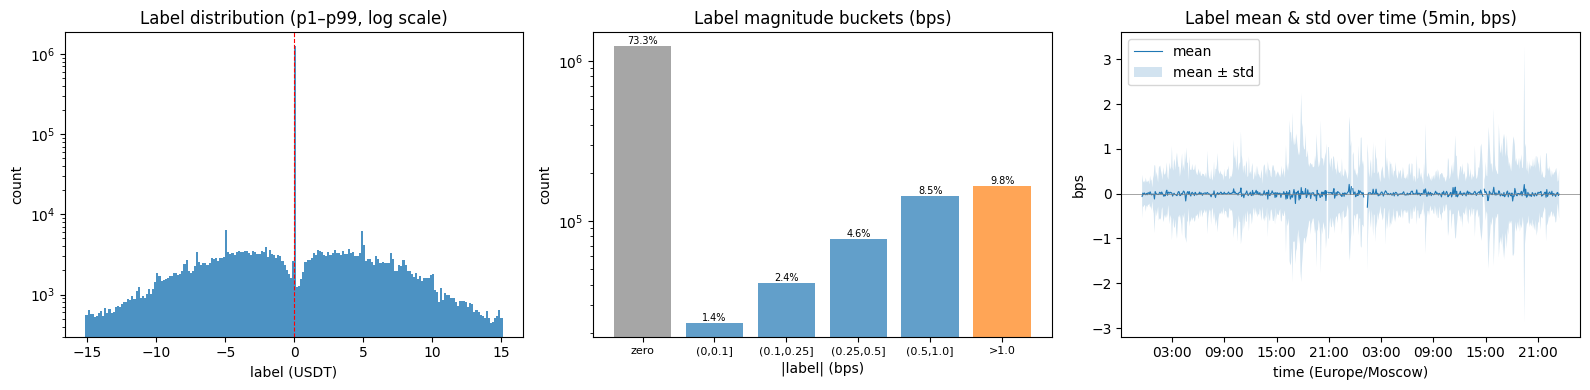

In [8]:
# --- Label distribution plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Histogram (log y)
ax = axes[0]
lo, hi, tag = _qrange(label, 0.01, 0.99)
ax.hist(label, bins=200, range=(lo, hi), edgecolor="none", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("label (USDT)")
ax.set_ylabel("count")
ax.set_title(f"Label distribution ({tag}, log scale)")
ax.axvline(0, color="red", ls="--", linewidth=0.8)

# 2. Magnitude buckets (bps)
ax = axes[1]
abs_bps = label_bps.abs()
edges = [0, 0.1, 0.25, 0.5, 1.0]
bucket_labels = ["zero"]
bucket_counts = [int((label == 0).sum())]
for i in range(len(edges) - 1):
    cnt = int(((abs_bps > edges[i]) & (abs_bps <= edges[i+1])).sum())
    bucket_labels.append(f"({edges[i]},{edges[i+1]}]")
    bucket_counts.append(cnt)
bucket_labels.append(f">{edges[-1]}")
bucket_counts.append(int((abs_bps > edges[-1]).sum()))
colors = ["gray"] + ["tab:blue"] * (len(edges) - 1) + ["tab:orange"]
ax.bar(range(len(bucket_labels)), bucket_counts, color=colors, alpha=0.7)
ax.set_xticks(range(len(bucket_labels)))
ax.set_xticklabels(bucket_labels, fontsize=8)
ax.set_yscale("log")
ax.set_xlabel("|label| (bps)")
ax.set_ylabel("count")
for i, cnt in enumerate(bucket_counts):
    if cnt > 0:
        ax.text(i, cnt, f"{cnt/len(label):.1%}", ha="center", va="bottom", fontsize=7)
ax.set_title("Label magnitude buckets (bps)")

# 3. Label over time
ax = axes[2]
lab_rs = ds.set_index("datetime")["label"].resample("5min")
lab_mean_bps = lab_rs.mean() / ref_price * 1e4
lab_std_bps = lab_rs.std() / ref_price * 1e4
ax.plot(lab_mean_bps.index, lab_mean_bps, linewidth=0.8, label="mean")
ax.fill_between(lab_mean_bps.index,
                lab_mean_bps - lab_std_bps, lab_mean_bps + lab_std_bps,
                alpha=0.2, label="mean ± std")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_ylabel("bps")
ax.set_title("Label mean & std over time (5min, bps)")
ax.legend()
_fmt_xaxis(ax, _TZ, TIMEZONE)

fig.tight_layout()
_save_fig(fig, "labels", OUTPUT_DIR)
plt.show()

## 6. Segment analysis

Detect segments from timestamp gaps (> `interval_ms`).
Large gaps indicate pipeline resets (sequence gap → re-bootstrap → warmup).
Per-segment stats help catch segments that are too short or have unstable labels.

In [9]:
attach_segment_id(ds, interval_ms)
seg_stats = ds.groupby("segment_id").agg(
    rows=("timestamp", "count"),
    start=("datetime", "min"),
    end=("datetime", "max"),
    label_mean=("label", "mean"),
    label_std=("label", "std"),
    label_zero_pct=("label", lambda x: (x == 0).mean()),
)
seg_stats["duration"] = seg_stats["end"] - seg_stats["start"]

print(f"=== {len(seg_stats)} segments ===")
print(seg_stats.to_string())

# Warn about short segments
short = seg_stats[seg_stats["rows"] < 100]
if len(short):
    print(f"\nWARNING: {len(short)} segments with <100 rows")

=== 5 segments ===
              rows                            start                              end  label_mean  label_std  label_zero_pct               duration
segment_id                                                                                                                                        
0           761148 2026-03-23 20:37:35.300000+00:00        2026-03-24 17:46:10+00:00   -0.026367   4.903319        0.713734 0 days 21:08:34.700000
1            95651 2026-03-24 17:57:05.600000+00:00 2026-03-24 20:36:30.600000+00:00    0.091523   5.058780        0.690646        0 days 02:39:25
2            45207 2026-03-24 20:47:02.100000+00:00 2026-03-24 22:02:22.700000+00:00    0.068244   5.246016        0.754861 0 days 01:15:20.600000
3           477273 2026-03-24 22:28:59.200000+00:00 2026-03-25 11:44:26.400000+00:00    0.030008   3.893402        0.815213 0 days 13:15:27.200000
4           307591 2026-03-25 11:54:58.100000+00:00 2026-03-25 20:27:37.100000+00:00   -0.030119   

## 7. Feature distributions & outliers

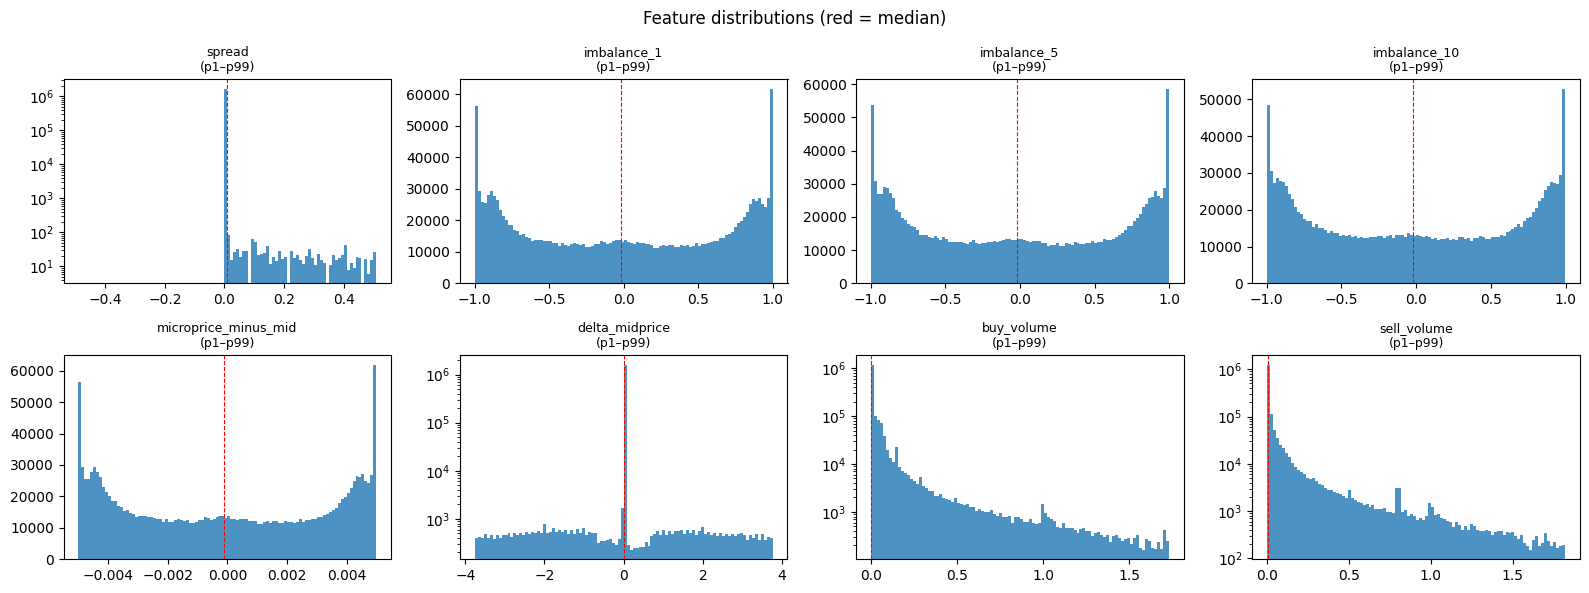

=== Feature Stats ===
              spread    imbalance_1    imbalance_5   imbalance_10  microprice_minus_mid  delta_midprice     buy_volume    sell_volume
count 1686870.000000 1686870.000000 1686870.000000 1686870.000000        1686870.000000  1686870.000000 1686870.000000 1686870.000000
mean        0.011577      -0.008281      -0.008170      -0.005919             -0.000022       -0.000192       0.105564       0.113381
std         0.091478       0.675881       0.675239       0.670361              0.037560        1.236256       1.028612       1.001049
min         0.010000      -0.999996      -0.999924      -0.999910             -9.251513      -73.565000       0.000000       0.000000
25%         0.010000      -0.671117      -0.670595      -0.658621             -0.003357        0.000000       0.000000       0.000000
50%         0.010000      -0.020304      -0.020025      -0.017840             -0.000102        0.000000       0.001020       0.001910
75%         0.010000       0.659335     

In [10]:
features = [c for c in FEATURE_COLUMNS if c in ds.columns]
missing = set(FEATURE_COLUMNS) - set(features)
if missing:
    print(f"Note: columns not in dataset, skipped: {missing}")

_log_y = {"spread", "delta_midprice", "buy_volume", "sell_volume"}
ncols = min(4, len(features))
nrows = (len(features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for ax, col in zip(np.array(axes).flat, features):
    data = ds[col]
    lo, hi, tag = _qrange(data, 0.01, 0.99)
    ax.hist(data, bins=100, range=(lo, hi), edgecolor="none", alpha=0.8)
    if col in _log_y:
        ax.set_yscale("log")
    ax.set_title(f"{col}\n({tag})", fontsize=9)
    ax.axvline(data.median(), color="red", ls="--", linewidth=0.8)
for ax in np.array(axes).flat[len(features):]:
    ax.set_visible(False)
fig.suptitle("Feature distributions (red = median)", fontsize=12)
fig.tight_layout()
_save_fig(fig, "features", OUTPUT_DIR)
plt.show()

print("=== Feature Stats ===")
print(ds[features].describe().round(6).to_string())

In [11]:
# --- Outlier check ---
outlier_cols = [c for c in ["spread", "delta_midprice", "buy_volume", "sell_volume", "label"]
                if c in ds.columns]
outlier_df = pd.DataFrame({
    "min": ds[outlier_cols].min(),
    "p0.1": ds[outlier_cols].quantile(0.001),
    "p99.9": ds[outlier_cols].quantile(0.999),
    "max": ds[outlier_cols].max(),
    "max/p99.9": (ds[outlier_cols].max() / ds[outlier_cols].quantile(0.999))
                 .replace([np.inf, -np.inf], np.nan),
})
print("=== Outlier Check ===")
print(outlier_df.round(4).to_string())
for col in outlier_cols:
    p999 = ds[col].quantile(0.999)
    col_max = ds[col].max()
    if p999 > 0 and col_max / p999 > 10:
        print(f"  WARNING: {col} max ({col_max:.2f}) is {col_max/p999:.0f}x p99.9 ({p999:.2f})")
    p001 = ds[col].quantile(0.001)
    col_min = ds[col].min()
    if p001 < 0 and col_min / p001 > 10:
        print(f"  WARNING: {col} min ({col_min:.2f}) is {col_min/p001:.0f}x p0.1 ({p001:.2f})")

=== Outlier Check ===
                       min       p0.1     p99.9        max  max/p99.9
spread            0.010000   0.010000  0.190000  33.950000 178.684200
delta_midprice  -73.565000 -10.700000 10.960700 158.285000  14.441200
buy_volume        0.000000   0.000000 10.433400 147.350800  14.123000
sell_volume       0.000000   0.000000 11.776400 105.317600   8.943100
label          -109.660000 -33.830000 34.096600 315.900000   9.264900


## 8. Feature ↔ label intuition

### 8a. Correlation overview

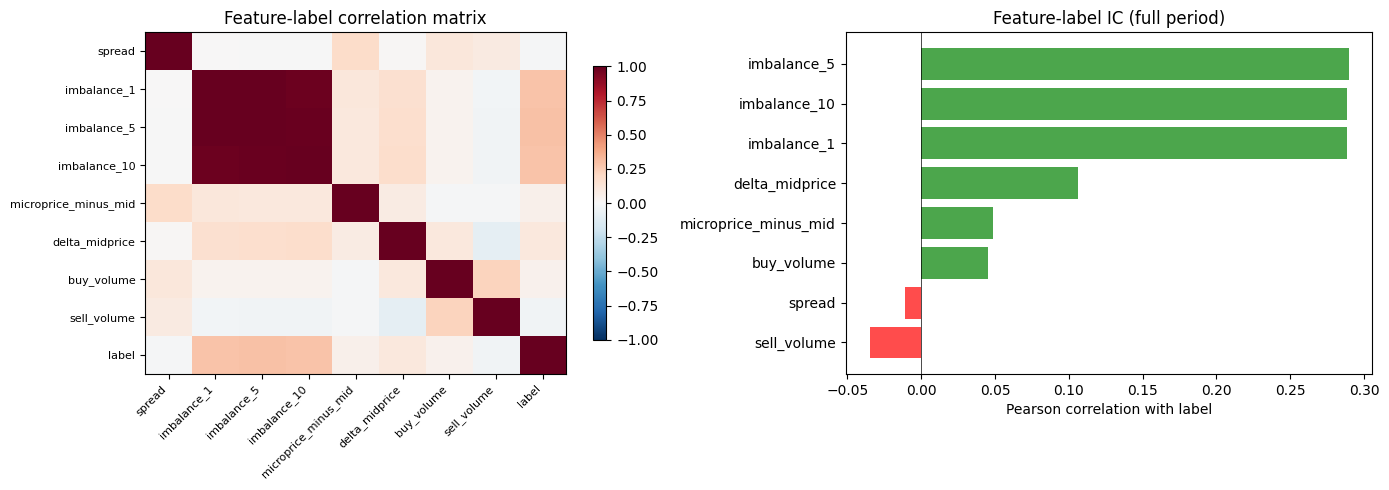

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
ax = axes[0]
corr = ds[features + ["label"]].corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature-label correlation matrix")

# IC bar chart
ax = axes[1]
ic = corr["label"].drop("label").sort_values()
colors = ["green" if v > 0 else "red" for v in ic]
ax.barh(ic.index, ic.values, color=colors, alpha=0.7)
ax.set_xlabel("Pearson correlation with label")
ax.set_title("Feature-label IC (full period)")
ax.axvline(0, color="black", linewidth=0.5)

fig.tight_layout()
_save_fig(fig, "feature_label_corr", OUTPUT_DIR)
plt.show()

In [13]:
# --- Hourly patterns ---
ds["hour"] = ds["datetime"].dt.tz_convert(TIMEZONE).dt.hour
dg = ds.groupby("hour")

ds_hourly = pd.DataFrame({
    "row_count": dg["label"].count(),
    "label_mean (bps)": dg["label"].mean() / ref_price * 1e4,
    "label_std (bps)": dg["label"].std() / ref_price * 1e4,
    "label_nonzero_pct": dg["label"].apply(lambda x: (x != 0).mean()),
    "avg_spread": dg["spread"].mean(),
    "avg_imbalance_1": dg["imbalance_1"].mean(),
})
ds_hourly.index.name = "hour_of_day"
print(f"=== Hourly Stats ({TIMEZONE}) ===")
with pd.option_context("display.max_columns", 15, "display.width", 180):
    print(ds_hourly.to_string())
_save_csv(ds_hourly, "hourly_stats", OUTPUT_DIR)

# IC by hour
print(f"\n=== Feature-label IC by hour ===")
ic_by_hour = ds.groupby("hour").apply(
    lambda g: g[features + ["label"]].corr()["label"].drop("label"),
    include_groups=False,
)
with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 180):
    print(ic_by_hour.to_string())
_save_csv(ic_by_hour, "ic_by_hour", OUTPUT_DIR)

=== Hourly Stats (Europe/Moscow) ===
             row_count  label_mean (bps)  label_std (bps)  label_nonzero_pct  avg_spread  avg_imbalance_1
hour_of_day                                                                                              
0                72000          0.003606         0.575118           0.159333    0.010598        -0.022949
1                56036         -0.005062         0.568207           0.206849    0.011065         0.001378
2                72000          0.007392         0.589610           0.209431    0.011163         0.029634
3                72000          0.001038         0.664802           0.265542    0.011964        -0.024635
4                72000         -0.006482         0.639225           0.246069    0.011654        -0.053484
5                72000         -0.004131         0.513951           0.216625    0.010521        -0.056082
6                72000          0.005440         0.464460           0.170361    0.010614        -0.019446
7        

### 8c. Feature → target bucket analysis (decile)

For each key feature, split into decile buckets and compute label statistics.
We look for **monotonicity** — a good feature should show monotonically increasing
(or decreasing) mean label across buckets.

Done per-horizon to see which features hold signal across time scales.

In [14]:
def bucket_stats(df, feature_col, label_col="label", n_buckets=10):
    """Compute label stats per feature decile bucket.
    
    Returns DataFrame with columns: bucket, count, mean_label, mean_label_ticks,
    p_up, p_down, feature_lo, feature_hi.
    """
    lbl = df[label_col]
    feat = df[feature_col]
    # Use qcut; for features with many ties, duplicates='drop'
    try:
        df_tmp = pd.DataFrame({
            "feat": feat,
            "label": lbl,
            "bucket": pd.qcut(feat, n_buckets, labels=False, duplicates="drop"),
        })
    except ValueError:
        return pd.DataFrame()
    
    grp = df_tmp.groupby("bucket")
    stats = pd.DataFrame({
        "count": grp["label"].count(),
        "mean_label": grp["label"].mean(),
        "mean_label_ticks": grp["label"].mean() / tick_size,
        "mean_label_bps": grp["label"].mean() / ref_price * 1e4,
        "p_up": grp["label"].apply(lambda x: (x > 0).mean()),
        "p_down": grp["label"].apply(lambda x: (x < 0).mean()),
        "feature_lo": grp["feat"].min(),
        "feature_hi": grp["feat"].max(),
    })
    return stats


BUCKET_FEATURES = ["microprice_minus_mid", "imbalance_1", "imbalance_5", "imbalance_10"]

# Run for each horizon in sweep
horizons_to_analyze = {}
if sweep_data:
    horizons_to_analyze = {k: v for k, v in sweep_data.items()}
else:
    # Fallback to primary dataset
    horizons_to_analyze = {str(horizon_ms): (ds, ds_meta)}

for h_key, (df_h, meta_h) in sorted(horizons_to_analyze.items(), key=lambda x: int(x[0])):
    print(f"\n{'='*60}")
    print(f"  HORIZON = {h_key} ms")
    print(f"{'='*60}")
    for feat in BUCKET_FEATURES:
        if feat not in df_h.columns:
            print(f"  {feat}: not in dataset, skipping")
            continue
        bs = bucket_stats(df_h, feat)
        if bs.empty:
            print(f"  {feat}: insufficient unique values for bucketing")
            continue
        # Check monotonicity of mean_label
        mean_vals = bs["mean_label"].values
        mono_up = all(mean_vals[i] <= mean_vals[i+1] for i in range(len(mean_vals)-1))
        mono_down = all(mean_vals[i] >= mean_vals[i+1] for i in range(len(mean_vals)-1))
        mono_tag = " ↗ MONOTONIC" if mono_up else (" ↘ MONOTONIC" if mono_down else "")
        print(f"\n--- {feat} (h={h_key}ms){mono_tag} ---")
        with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 180):
            print(bs.to_string())


  HORIZON = 200 ms

--- microprice_minus_mid (h=200ms) ↗ MONOTONIC ---
         count  mean_label  mean_label_ticks  mean_label_bps   p_up  p_down  feature_lo  feature_hi
bucket                                                                                             
0       168691     -1.0488         -104.8846         -0.1500 0.0028  0.2418     -9.2515     -0.0045
1       168693     -0.2674          -26.7357         -0.0382 0.0034  0.0678     -0.0045     -0.0039
2       168689     -0.1665          -16.6499         -0.0238 0.0049  0.0425     -0.0039     -0.0028
3       168691     -0.0753           -7.5321         -0.0108 0.0073  0.0240     -0.0028     -0.0014
4       168692     -0.0161           -1.6094         -0.0023 0.0102  0.0145     -0.0014     -0.0001
5       168690      0.0204            2.0399          0.0029 0.0143  0.0106     -0.0001      0.0012
6       168691      0.0755            7.5535          0.0108 0.0236  0.0078      0.0012      0.0027
7       168691      0.1629  

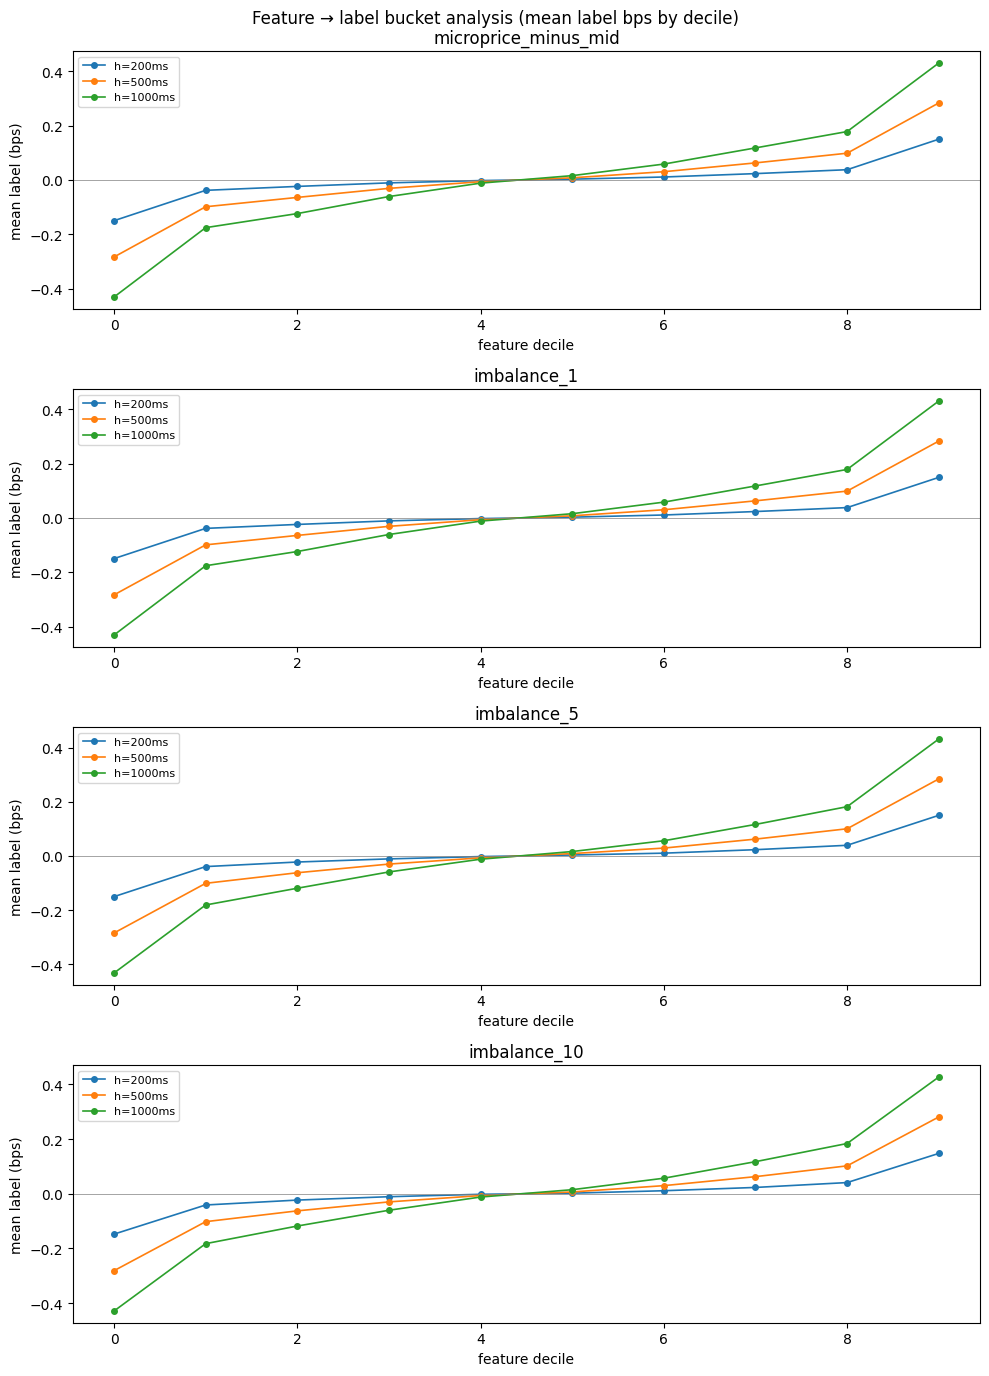

In [15]:
# --- Bucket analysis plots: mean_label_bps by decile for each feature x horizon ---
if sweep_data:
    n_feats = len(BUCKET_FEATURES)
    n_horizons = len(sweep_data)
    fig, axes = plt.subplots(n_feats, 1, figsize=(10, 3.5 * n_feats), sharex=False)
    if n_feats == 1:
        axes = [axes]
    
    for ax, feat in zip(axes, BUCKET_FEATURES):
        for h_key, (df_h, _) in sorted(sweep_data.items(), key=lambda x: int(x[0])):
            if feat not in df_h.columns:
                continue
            bs = bucket_stats(df_h, feat)
            if bs.empty:
                continue
            ax.plot(bs.index, bs["mean_label_bps"], marker="o", markersize=4,
                    label=f"h={h_key}ms", linewidth=1.2)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.set_ylabel("mean label (bps)")
        ax.set_xlabel("feature decile")
        ax.set_title(f"{feat}")
        ax.legend(fontsize=8)
    
    fig.suptitle("Feature → label bucket analysis (mean label bps by decile)", fontsize=12)
    fig.tight_layout()
    _save_fig(fig, "bucket_analysis", OUTPUT_DIR)
    plt.show()

---
## 9. Raw data context (optional)

Lightweight book replay and trade statistics from raw recorded data.
Provides market regime context (midprice, spread, volatility, depth).
Set `RAW_DATA_PATH = None` to skip this section entirely.

In [16]:
if not HAS_RAW:
    print("No raw data — skipping.")
else:
    print(f"Events: {len(raw_df):,}  |  Trades: {len(trades):,}")
    print(f"Time: {raw_df.datetime.min()} — {raw_df.datetime.max()}")
    print(f"Event types: {raw_df.event_type.value_counts().to_dict()}")
    print(f"Book samples: {len(book_df):,}  |  Segments: {book_df.segment_id.nunique()}")

Events: 20,273,834  |  Trades: 16,270,563
Time: 2026-03-23 20:27:34.402000+00:00 — 2026-03-28 12:00:00.316000+00:00
Event types: {'trade': 16270563, 'depthUpdate': 4003263, 'depthSnapshot': 8}
Book samples: 400,426  |  Segments: 8


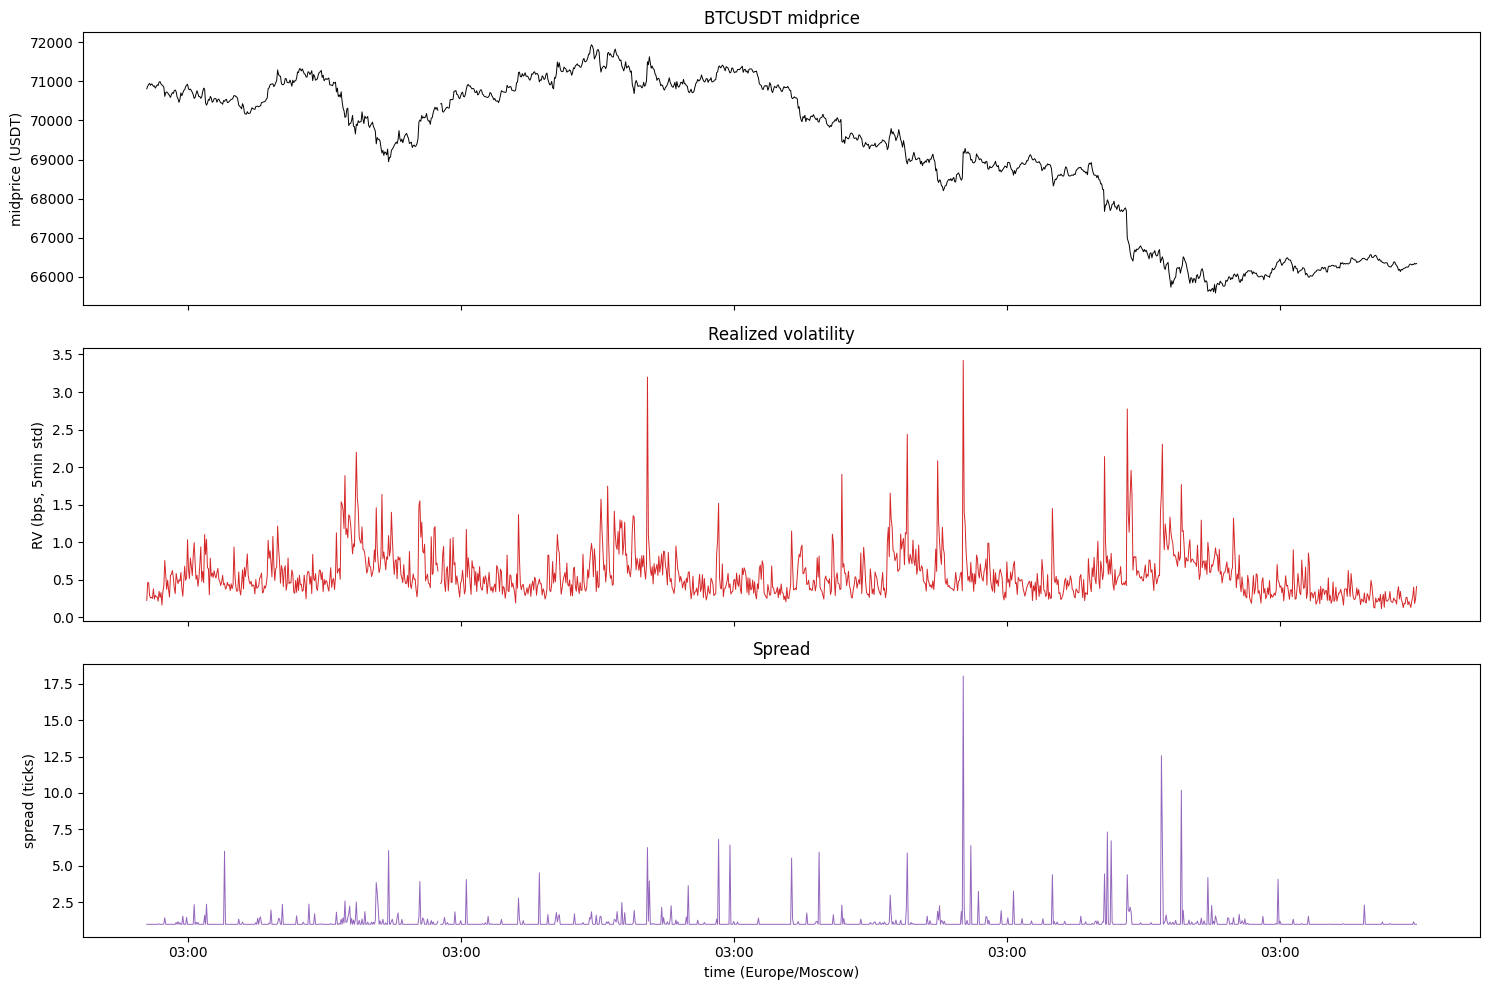

=== Raw Data Summary ===
  period: 2026-03-23 20:27:35+00:00 — 2026-03-28 12:01:00+00:00
  midprice_range: 65549.12 — 72026.09
  avg_spread (ticks): 1.18
  1-tick spread pct: 99.9%
  trades: 16,270,563
  total_notional (USDT): 6,570,625,199
  buy_pct: 49.1%


In [17]:
if HAS_RAW:
    bk = book_df.set_index("datetime")
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

    # Midprice
    mid_rs = bk["midprice"].resample(PLOT_RESAMPLE).last()
    axes[0].plot(mid_rs, linewidth=0.7, color="black")
    axes[0].set_ylabel("midprice (USDT)")
    axes[0].set_title(f"{SYMBOL} midprice")

    # Realized volatility
    rv = bk["log_return"].resample("5min").std() * 1e4
    axes[1].plot(rv, linewidth=0.7, color="tab:red")
    axes[1].set_ylabel("RV (bps, 5min std)")
    axes[1].set_title("Realized volatility")

    # Spread
    sp_rs = bk["spread_ticks"].resample(PLOT_RESAMPLE).mean()
    axes[2].plot(sp_rs, linewidth=0.7, color="tab:purple")
    axes[2].set_ylabel("spread (ticks)")
    axes[2].set_title("Spread")
    _fmt_xaxis(axes[2], _TZ, TIMEZONE)

    fig.tight_layout()
    _save_fig(fig, "raw_overview", OUTPUT_DIR)
    plt.show()

    # Summary
    print("=== Raw Data Summary ===")
    summary = {
        "period": f"{book_df.datetime.min()} — {book_df.datetime.max()}",
        "midprice_range": f"{book_df.midprice.min():.2f} — {book_df.midprice.max():.2f}",
        "avg_spread (ticks)": f"{book_df.spread_ticks.mean():.2f}",
        "1-tick spread pct": f"{(book_df.spread_ticks == 1).mean():.1%}",
    }
    if not trades.empty:
        summary["trades"] = f"{len(trades):,}"
        summary["total_notional (USDT)"] = f"{trades.notional.sum():,.0f}"
        summary["buy_pct"] = f"{(trades.side == 'buy').mean():.1%}"
    for k, v in summary.items():
        print(f"  {k}: {v}")

---
## 10. Research verdict

Based on horizon sweep, tradeability analysis, and feature → target bucket analysis.

In [18]:
print("""
=== RESEARCH VERDICT ===

Primary horizon:    500ms
  - Good balance: 83.7% zero-label vs 73.3% at 1000ms (less noise),
    but enough non-zero moves for signal (~16% non-zero).
  - Imbalance features perfectly monotonic across deciles.
  - Mean |label| ~0.14 bps — tight but above noise floor.

Secondary horizon:  1000ms
  - More non-zero labels (26.7%), stronger bucket separation (~0.43 bps in tails).
  - Higher IC overall. Good fallback if 500ms signal proves too weak after fees.

Most promising features (all monotonic across all horizons):
  - imbalance_1 / imbalance_5 / imbalance_10: near-perfect monotonicity,
    IC ~0.28-0.36 with label. Tail buckets show p_up ~47% vs p_down ~3% (h=1000ms).
  - microprice_minus_mid: equally strong, essentially equivalent to imbalance signal
    (both derive from LOB shape).

Main risks:
  - High label_zero_pct (73-92%): vast majority of intervals have zero midprice change.
    Model must learn to NOT trade most of the time.
  - Tradeability: at fee_bps=4, nearly 100% of labels are below fee threshold in bps.
    This means raw midprice-change prediction alone won't produce profitable trades.
    Need either: (a) very high signal concentration in tails, or (b) sub-tick alpha
    exploiting queue position / spread capture, not just midprice direction.
  - Only ~48h of data (5 segments). Regime stability is unknown.

Ready for baseline modeling: YES
  Signal structure is clean and monotonic. Next step: train a simple model
  (logistic or small tree) on 500ms horizon, evaluate on forward segment,
  and measure conditional E[label | prediction] in the extreme buckets.
""")

if SAVE_OUTPUTS:
    print(f"\nArtifacts saved to {OUTPUT_DIR}")
    for f in sorted(OUTPUT_DIR.glob("*")):
        print(f"  {f.name}")
else:
    print("SAVE_OUTPUTS=False — set to True and re-run to save artifacts.")


=== RESEARCH VERDICT ===

Primary horizon:    500ms
  - Good balance: 83.7% zero-label vs 73.3% at 1000ms (less noise),
    but enough non-zero moves for signal (~16% non-zero).
  - Imbalance features perfectly monotonic across deciles.
  - Mean |label| ~0.14 bps — tight but above noise floor.

Secondary horizon:  1000ms
  - More non-zero labels (26.7%), stronger bucket separation (~0.43 bps in tails).
  - Higher IC overall. Good fallback if 500ms signal proves too weak after fees.

Most promising features (all monotonic across all horizons):
  - imbalance_1 / imbalance_5 / imbalance_10: near-perfect monotonicity,
    IC ~0.28-0.36 with label. Tail buckets show p_up ~47% vs p_down ~3% (h=1000ms).
  - microprice_minus_mid: equally strong, essentially equivalent to imbalance signal
    (both derive from LOB shape).

Main risks:
  - High label_zero_pct (73-92%): vast majority of intervals have zero midprice change.
    Model must learn to NOT trade most of the time.
  - Tradeability: at 